In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('diabetes_data_upload.csv')

# Kiểm tra dữ liệu
print(data.head())

   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial paresis muscle stiffness Alopecia Obesity     class  
0              No              Yes      

In [4]:
# Chuyển đổi các giá trị phân loại thành số (nếu cần thiết)
data['class'] = data['class'].map({'Positive': 1, 'Negative': 0})
data = pd.get_dummies(data, drop_first=True)  # Mã hóa các biến phân loại

In [5]:
# Xử lý các giá trị thiếu (nếu có)
data.dropna(inplace=True)

In [6]:
# Tách các biến đầu vào (X) và biến mục tiêu (y)
X = data.drop('class', axis=1)
y = data['class']


In [7]:
# Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Tạo mô hình hồi quy logistic
model = LogisticRegression(max_iter=1000)
# Huấn luyện mô hình
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
# Dự đoán kết quả trên tập kiểm tra
y_pred = model.predict(X_test)

In [11]:
# Đánh giá mô hình
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Confusion Matrix:
[[49  5]
 [ 5 97]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        54
           1       0.95      0.95      0.95       102

    accuracy                           0.94       156
   macro avg       0.93      0.93      0.93       156
weighted avg       0.94      0.94      0.94       156

Accuracy: 0.94


In [12]:
#Phân tích hệ số hồi quy
coefficients = pd.DataFrame(model.coef_[0], X.columns,
columns=['Coefficient'])
print("\nHệ số hồi quy:")
print(coefficients)


Hệ số hồi quy:
                        Coefficient
Age                       -0.437207
Gender_Male               -1.439712
Polyuria_Yes               1.580081
Polydipsia_Yes             1.725323
sudden weight loss_Yes     0.439123
weakness_Yes               0.319438
Polyphagia_Yes             0.176856
Genital thrush_Yes         0.703433
visual blurring_Yes        0.489204
Itching_Yes               -0.970290
Irritability_Yes           0.745280
delayed healing_Yes       -0.316720
partial paresis_Yes        0.576305
muscle stiffness_Yes      -0.191007
Alopecia_Yes               0.039812
Obesity_Yes               -0.105719


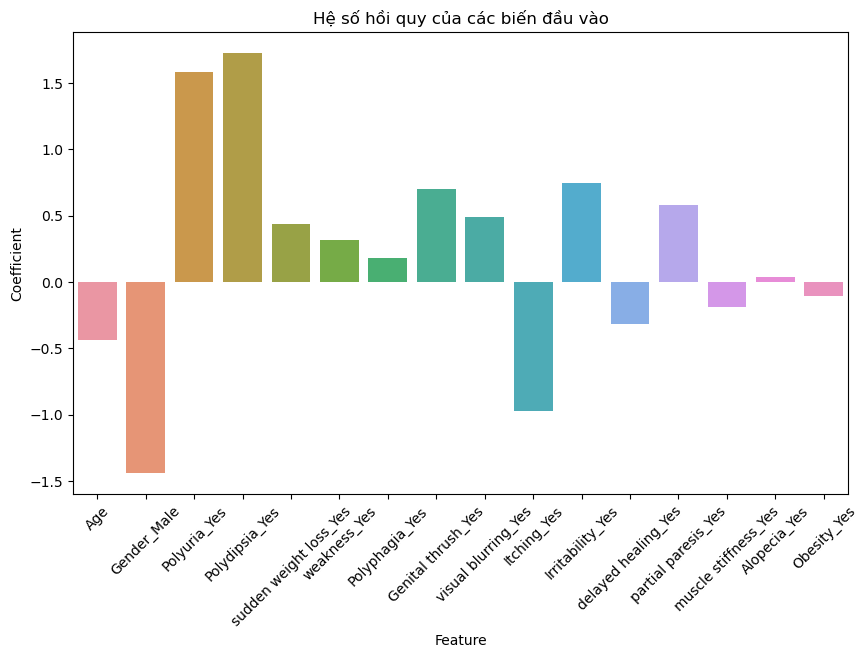

In [13]:
# Trực quan hóa các hệ số hồi quy
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', data=coefficients)
plt.xticks(rotation=45)
plt.title("Hệ số hồi quy của các biến đầu vào")
plt.show()
